In [2]:
import kagglehub
import os
import pandas as pd

# Download dataset
path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Dataset path:", path)
print(os.listdir(path))

# Load accepted loans
file_path = os.path.join(path, "accepted_2007_to_2018Q4.csv.gz")

df = pd.read_csv(
    file_path,
    low_memory=False
)

print(df.shape)

100%|██████████| 1.26G/1.26G [02:05<00:00, 10.8MB/s]

Extracting files...


Dataset path: C:\Users\Bintou\.cache\kagglehub\datasets\wordsforthewise\lending-club\versions\3
['accepted_2007_to_2018q4.csv', 'accepted_2007_to_2018Q4.csv.gz', 'rejected_2007_to_2018q4.csv', 'rejected_2007_to_2018Q4.csv.gz']
(2260701, 151)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), str(38)
memory usage: 2.5 GB


In [4]:
df.columns.tolist()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

In [5]:
# Keeping only information available at application time
# Removing features that leak future loan outcomes
# Dropping identifiers and text fields that are not useful for modeling


cols_to_drop = [
    'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv', 'verification_status_joint',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt','next_pymnt_d',
    'last_credit_pull_d','last_fico_range_high', 'last_fico_range_low',
    'id', 'member_id','url', 'desc', 'title', 'emp_title',
    'zip_code', 'funded_amnt','funded_amnt_inv',
    'grade','sub_grade','annual_inc_joint','dti_joint',
    'revol_bal_joint','policy_code','initial_list_status','deferral_term',
    'orig_projected_additional_accrued_interest', 'payment_plan_start_date'
]


prefixes_to_drop = ('hardship_', 'debt_settlement_', 'settlement_')

cols_to_drop += [c for c in df.columns if c.startswith(prefixes_to_drop)]

df = df.drop(columns=list(set([c for c in cols_to_drop if c in df.columns])))



sec_app_cols = [c for c in df.columns if c.startswith('sec_app_')]

df = df.drop(columns=sec_app_cols)

In [6]:
df["loan_status"].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [7]:
#Keeping only loans with final outcomes

keep = [
    'Fully Paid',
    'Charged Off',
    'Default'
]

df = df[df['loan_status'].isin(keep)]

In [8]:
#missing values

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

df.isnull().sum()

loan_amnt                               0
term                                    0
int_rate                                0
installment                             0
emp_length                          78516
home_ownership                          0
annual_inc                              0
verification_status                     0
issue_d                                 0
loan_status                             0
pymnt_plan                              0
purpose                                 0
addr_state                              0
dti                                   374
delinq_2yrs                             0
earliest_cr_line                        0
fico_range_low                          0
fico_range_high                         0
inq_last_6mths                          1
mths_since_last_delinq             678761
mths_since_last_record            1116786
open_acc                                0
pub_rec                                 0
revol_bal                         

In [9]:
#convert to integers

df['term'] = df['term'].str.extract('(\d+)').astype(int)

df['emp_length'] = (
    df['emp_length']
    .str.replace(r'\+ years', '', regex=True)
    .str.replace(r' years?', '', regex=True)
    .str.replace(r'< 1', '0', regex=False)
)

df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce')

# Convert to datetime
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')

df['credit_history_length'] = (
    (df['issue_d'] - df['earliest_cr_line']).dt.days / 365.25
).round(1)


df.drop(columns=['issue_d', 'earliest_cr_line'], inplace=True)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Bintou\AppData\Local\Temp\ipykernel_20616\3305869814.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['term'] = df['term'].str.extract('(\d+)').astype(int)


In [10]:
df.select_dtypes(include='object').columns

C:\Users\Bintou\AppData\Local\Temp\ipykernel_20616\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['home_ownership', 'verification_status', 'loan_status', 'pymnt_plan',
       'purpose', 'addr_state', 'application_type', 'disbursement_method'],
      dtype='str')

In [11]:
for col in ['pymnt_plan', 'disbursement_method', 'home_ownership', 'verification_status', 'loan_status', 'purpose',
       'addr_state', 'application_type', 'disbursement_method']:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


 pymnt_plan
pymnt_plan
n    1345350
Name: count, dtype: int64

 disbursement_method
disbursement_method
Cash         1338450
DirectPay       6900
Name: count, dtype: int64

 home_ownership
home_ownership
MORTGAGE    665596
RENT        534436
OWN         144840
ANY            286
OTHER          144
NONE            48
Name: count, dtype: int64

 verification_status
verification_status
Source Verified    521289
Verified           418352
Not Verified       405709
Name: count, dtype: int64

 loan_status
loan_status
Fully Paid     1076751
Charged Off     268559
Default             40
Name: count, dtype: int64

 purpose
purpose
debt_consolidation    780342
credit_card           295285
home_improvement       87507
other                  77877
major_purchase         29427
medical                15556
small_business         15416
car                    14588
moving                  9480
vacation                9065
house                   7254
wedding                 2294
renewable_energy      

In [12]:
#Dropped because it has only 1 unique value

df.drop(columns=['pymnt_plan'], inplace=True)

In [13]:
df.shape

(1345350, 83)

In [14]:
df.head(10)

,loan_amnt,term,int_rate,installment,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,addr_state,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,mths_since_last_major_derog,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,credit_history_length
0,3600.0,36,13.99,123.03,10.0,MORTGAGE,55000.0,Not Verified,Fully Paid,debt_consolidation,PA,5.91,0.0,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,0.0,30.0,Individual,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash,12.3
1,24700.0,36,11.99,820.28,10.0,MORTGAGE,65000.0,Not Verified,Fully Paid,small_business,SD,16.06,1.0,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,0.0,NaN,Individual,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash,16.0
2,20000.0,60,10.78,432.66,10.0,MORTGAGE,63000.0,Not Verified,Fully Paid,home_improvement,IL,10.78,0.0,695.0,699.0,0.0,NaN,NaN,6.0,0.0,7869.0,56.2,18.0,0.0,NaN,Joint App,0.0,0.0,189699.0,0.0,1.0,0.0,4.0,19.0,10827.0,73.0,0.0,2.0,2081.0,65.0,14000.0,2.0,5.0,1.0,6.0,31617.0,2737.0,55.9,0.0,0.0,125.0,184.0,14.0,14.0,5.0,101.0,NaN,10.0,NaN,0.0,2.0,3.0,2.0,4.0,6.0,4.0,7.0,3.0,6.0,0.0,0.0,0.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,Cash,15.3
4,10400.0,60,22.45,289.91,3.0,MORTGAGE,104433.0,Source Verified,Fully Paid,major_purchase,PA,25.37,1.0,695.0,699.0,3.0,12.0,NaN,12.0,0.0,21929.0,64.5,35.0,0.0,NaN,Individual,0.0,0.0,331730.0,1.0,3.0,0.0,3.0,14.0,73839.0,84.0,4.0,7.0,9702.0,78.0,34000.0,2.0,1.0,3.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,12.0,1.0,12.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,Cash,17.5
5,11950.0,36,13.44,405.18,4.0,RENT,34000.0,Source Verified,Fully Paid,debt_consolidation,GA,10.20,0.0,690.0,694.0,0.0,NaN,NaN,5.0,0.0,8822.0,68.4,6.0,0.0,NaN,Individual,0.0,0.0,12798.0,0.0,1.0,0.0,0.0,338.0,3976.0,99.0,0.0,0.0,4522.0,76.0,12900.0,0.0,0.0,0.0,0.0,2560.0,844.0,91.0,0.0,0.0,338.0,54.0,32.0,32.0,0.0,36.0,NaN,NaN,NaN,0.0,2.0,3.0,2.0,2.0,2.0,4.0,4.0,3.0,5.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,Cash,28.2
6,20000.0,36,9.17,637.58,10.0,MORTGAGE,180000.0,Not Verified,Fully Paid,debt_consolidation,MN,14.67,0.0,680.0,684.0,0.0,49.0,NaN,12.0,0.0,87329.0,84.5,27.0,0.0,NaN,Individual,0.0,0.0,360358.0,0.0,2.0,0.0,2.0,18.0,29433.0,63.0,2.0,3.0,13048.0,74.0,94200.0,1.0,0.0,1.0,6.0,30030.0,0.0,102.9,0.0,0.0,142.0,306.0,10.0,10.0,4.0,12.0,NaN,10.0,NaN,0.0,4.0,6.0,4.0,5.0,7.0,9.0,16.0,6.0,12.0,0.0,0.0,0.0,2.0,96.3,100.0,0.0,0.0,388852.0,116762.0,31500.0,46452.0,Cash,25.5
7,20000.0,36,8.49,631.26,10.0

In [15]:
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100

missing_df = missing_pct.reset_index()
missing_df.columns = ['column', 'missing_percentage']

missing_df = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_df = missing_df[missing_df > 0]

missing_df

mths_since_last_record            83.010815
mths_since_recent_bc_dlq          76.286543
mths_since_last_major_derog       73.705207
mths_since_recent_revol_delinq    66.553239
il_util                           65.433010
mths_since_rcnt_il                61.094213
all_util                          60.041402
total_cu_tl                       60.037537
inq_last_12m                      60.037537
open_acc_6m                       60.037537
inq_fi                            60.037462
open_il_12m                       60.037462
open_rv_24m                       60.037462
open_il_24m                       60.037462
open_act_il                       60.037462
max_bal_bc                        60.037462
open_rv_12m                       60.037462
total_bal_il                      60.037462
mths_since_last_delinq            50.452373
mths_since_recent_inq             12.938863
num_tl_120dpd_2m                   8.726577
mo_sin_old_il_acct                 7.847475
emp_length                      

In [16]:
df.columns.tolist()

['loan_amnt',
 'term',
 'int_rate',
 'installment',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'loan_status',
 'purpose',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'application_type',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort_acc',
 'mths_since_recent_bc',
 'm

In [17]:
df.shape

(1345350, 83)

In [18]:
#Version 1: Informative missingness indicators
df_indicator = df.copy()

In [19]:
# Event-based columns: -1 + indicator

event_cols = [
    'mths_since_last_delinq',
    'mths_since_last_record',
    'mths_since_last_major_derog',
    'mths_since_recent_bc_dlq',
    'mths_since_recent_revol_delinq',
    'mths_since_recent_inq'
]

for col in event_cols:
    if col in df_indicator.columns:
        df_indicator[col + '_missing'] = df_indicator[col].isna().astype(int)
        df_indicator[col] = df_indicator[col].fillna(-1)



# Remaining numeric columns
numeric_cols = df_indicator.select_dtypes(include='number').columns


exclude_cols = ['loan_status']

# Excluding the event columns
median_cols = [
    col for col in numeric_cols
    if col not in event_cols
    and col not in exclude_cols
]

for col in median_cols:
    missing_pct = df_indicator[col].isna().mean() * 100

    # Create indicators only for columns with meaningful missingness
    if missing_pct >= 5:
        df_indicator[col + '_missing'] = df_indicator[col].isna().astype(int)

    # Fill with median
    if df_indicator[col].isna().sum() > 0:
        df_indicator[col] = df_indicator[col].fillna(df_indicator[col].median())

C:\Users\Bintou\AppData\Local\Temp\ipykernel_20616\691279455.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_indicator[col + '_missing'] = df_indicator[col].isna().astype(int)
C:\Users\Bintou\AppData\Local\Temp\ipykernel_20616\691279455.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_indicator[col + '_missing'] = df_indicator[col].isna().astype(int)
C:\Users\Bintou\AppData\Local\Temp\ipykernel_20616\691279455.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.

In [20]:
df_indicator.isnull().sum()

loan_amnt                                 0
term                                      0
int_rate                                  0
installment                               0
emp_length                                0
home_ownership                            0
annual_inc                                0
verification_status                       0
loan_status                               0
purpose                                   0
addr_state                                0
dti                                       0
delinq_2yrs                               0
fico_range_low                            0
fico_range_high                           0
inq_last_6mths                            0
mths_since_last_delinq                    0
mths_since_last_record                    0
open_acc                                  0
pub_rec                                   0
revol_bal                                 0
revol_util                                0
total_acc                       

In [21]:
df_indicator.shape

(1345350, 127)

In [22]:
df_indicator.head(10)

,loan_amnt,term,int_rate,installment,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,addr_state,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,mths_since_last_major_derog,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,credit_history_length,mths_since_last_delinq_missing,mths_since_last_record_missing,mths_since_last_major_derog_missing,mths_since_recent_bc_dlq_missing,mths_since_recent_revol_delinq_missing,mths_since_recent_inq_missing,emp_length_missing,tot_coll_amt_missing,tot_cur_bal_missing,open_acc_6m_missing,open_act_il_missing,open_il_12m_missing,open_il_24m_missing,mths_since_rcnt_il_missing,total_bal_il_missing,il_util_missing,open_rv_12m_missing,open_rv_24m_missing,max_bal_bc_missing,all_util_missing,total_rev_hi_lim_missing,inq_fi_missing,total_cu_tl_missing,inq_last_12m_missing,avg_cur_bal_missing,mo_sin_old_il_acct_missing,mo_sin_old_rev_tl_op_missing,mo_sin_rcnt_rev_tl_op_missing,mo_sin_rcnt_tl_missing,num_accts_ever_120_pd_missing,num_actv_bc_tl_missing,num_actv_rev_tl_missing,num_bc_tl_missing,num_il_tl_missing,num_op_rev_tl_missing,num_rev_accts_missing,num_rev_tl_bal_gt_0_missing,num_tl_120dpd_2m_missing,num_tl_30dpd_missing,num_tl_90g_dpd_24m_missing,num_tl_op_past_12m_missing,pct_tl_nvr_dlq_missing,tot_hi_cred_lim_missing,total_il_high_credit_limit_missing
0,3600.0,36,13.99,123.03,10.0,MORTGAGE,55000.0,Not Verified,Fully Paid,debt_consolidation,PA,5.91,0.0,675.0,679.0,1.0,30.0,-1.0,7.0,0.0,2765.0,29.7,13.0,0.0,30.0,Individual,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash,12.3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,24700.0,36,11.99,820.28,10.0,MORTGAGE,65000.0,Not Verified,Fully Paid,small_business,SD,16.06,1.0,715.0,719.0,4.0,6.0,-1.0,22.0,0.0,21470.0,19.2,38.0,0.0,-1.0,Individual,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,-1.0,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash,16.0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,20000.0,60,10.78,432.66,10.0,MORTGAGE,63000.0,Not Verified,Fully Paid,home_improvement,IL,10.78,0.0,695.0,699.0,0.0,-1.0,-1.0,6.0,0.0,7869.0,56.2,18.0,0.0,-1.0,Joint App,0.0,0.0,189699.0,0.0,1.0,0.0,4.0,19.0,10827.0,73.0,0.0,2.0,2081.0,65.0,14000.0,2.0,5.0,1.0,6.0,31617.0,2737.0,55.9,0.0,0.0,125.0,184.0,14.0,14.0,5.0,101.0,-1.0,10.0,-1.0,0.0,2.0,3.0,2.0,4.0,6.0,4.0,7.0,3.0,6.0,0.0,0.0,0.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,Cash,15.3,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,10400.0,60,22.45,289.91,3.0,MORTGAGE,104433.0,Source Verified,Full

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#version 2: Graph
#df_graph=df_indicator.copy()

SyntaxError: invalid syntax (2278122425.py, line 5)

# Count
print(df_graph['loan_status'].value_counts())

# Percentage
print(df_graph['loan_status'].value_counts(normalize=True) * 100)

#Plot
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df_graph)
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

feature_groups = {
    'Loan Terms': [
        'loan_amnt', 'term', 'int_rate', 'installment'
    ],

    'Borrower Strength': [
        'annual_inc', 'dti',
        'fico_range_low', 'fico_range_high'
    ],

    'Credit History': [
        'delinq_2yrs', 'inq_last_6mths',
        'open_acc', 'total_acc',
        'pub_rec', 'pub_rec_bankruptcies',
        'tax_liens'
    ],

    'Utilization': [
        'revol_bal', 'revol_util',
        'bc_util', 'all_util', 'il_util'
    ],

    'Delinquency Timing': [
        'mths_since_last_delinq',
        'mths_since_last_record',
        'mths_since_last_major_derog',
        'mths_since_recent_inq',
        'mths_since_recent_bc_dlq',
        'mths_since_recent_revol_delinq'
    ]
}

#Loan Characteristics:
#Histogram

for col in ['loan_amnt','int_rate','installment']:

    plt.figure(figsize=(7,4))
    sns.histplot(df_graph[col], bins=50)
    plt.title(f'Distribution of {col}')
    plt.show()

#Boxplots by Loan Status

for col in ['loan_amnt','int_rate','installment']:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        x='loan_status',
        y=col,
        data=df_graph
    )

    plt.title(f'{col} by Loan Status')
    plt.show()

#Default Rate by Term

print(df_graph['term'].value_counts())

term_rate = (
    pd.crosstab(
        df_graph['term'],
        df_graph['loan_status'],
        normalize='index'
    ) * 100
)

term_rate.plot(kind='bar')

plt.title('Default Rate by Loan Term')
plt.ylabel('Percentage')

plt.show()

#Borrower Strength group

df_graph['fico_avg'] = (df_graph['fico_range_low']+ df_graph['fico_range_high'])/2

for col in ['annual_inc','dti','fico_avg']:

    plt.figure(figsize=(7,4))
    sns.histplot(df_graph[col], bins=50)
    plt.title(f'Distribution of {col}')
    plt.show()

for col in ['annual_inc','dti','fico_avg']:

    plt.figure(figsize=(7,4))
    sns.boxplot(
        x='loan_status',
        y=col,
        data=df_graph
    )

    plt.title(f'{col} by Loan Status')
    plt.show()

#Default rate by FICO quintiles

df_graph['fico_bin'] = pd.qcut(
    df_graph['fico_avg'],
    q=5
)

fico_rate = (
    pd.crosstab(
        df_graph['fico_bin'],
        df_graph['loan_status'],
        normalize='index'
    ) * 100
)

fico_rate.plot(kind='bar')

plt.title('Default Rate by FICO Group')
plt.ylabel('Percentage')

plt.show()

#Credit History group

for col in ['delinq_2yrs',
            'inq_last_6mths',
            'pub_rec_bankruptcies']:

    print(df_graph[col].value_counts().head(10))

#Default rate by count

for col in ['delinq_2yrs',
            'inq_last_6mths',
            'pub_rec_bankruptcies']:

    rate = (
        pd.crosstab(
            df_graph[col],
            df_graph['loan_status'],
            normalize='index'
        ) * 100
    )

    rate.head(10).plot(kind='bar')
    plt.title(f'Default Rate by {col}')
    plt.ylabel('Percentage')
    plt.show()

for col in ['open_acc','total_acc']:

    plt.figure(figsize=(7,4))
    sns.boxplot(
        x='loan_status',
        y=col,
        data=df_graph
    )

    plt.title(f'{col} by Loan Status')
    plt.show()

#Utilization group

for col in feature_groups['Utilization']:

    plt.figure(figsize=(7,4))
    sns.histplot(df_graph[col], bins=50)
    plt.title(f'Distribution of {col}')
    plt.show()

for col in feature_groups['Utilization']:

    plt.figure(figsize=(7,4))
    sns.boxplot(
        x='loan_status',
        y=col,
        data=df_graph
    )

    plt.title(f'{col} by Loan Status')
    plt.show()

cat_features = [
    'home_ownership',
    'verification_status',
    'purpose',
    'application_type',
    'disbursement_method'
]

for col in cat_features:

    rate = (
        pd.crosstab(
            df_graph[col],
            df_graph['loan_status'],
            normalize='index'
        ) * 100
    )

    rate.plot(
        kind='bar',
        figsize=(8,4)
    )

    plt.title(f'Default Rate by {col}')
    plt.ylabel('Percentage')
    plt.show()

In [27]:
import numpy as np

#Correlation matrix feature-feature: checking for redundancy

corr_features = [
    'loan_amnt','int_rate','installment','annual_inc','dti',
    'fico_range_low','fico_range_high','delinq_2yrs','inq_last_6mths','open_acc',
    'pub_rec','revol_bal','revol_util','total_acc',
    'acc_now_delinq','tot_coll_amt','tot_cur_bal',
    'open_acc_6m','open_act_il','open_il_12m',
    'open_il_24m','total_bal_il','il_util',
    'open_rv_12m','open_rv_24m','max_bal_bc',
    'all_util','total_rev_hi_lim','inq_fi',
    'total_cu_tl','inq_last_12m',
    'acc_open_past_24mths','avg_cur_bal',
    'bc_open_to_buy','bc_util',
    'chargeoff_within_12_mths','delinq_amnt',
    'mo_sin_old_il_acct','mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op','mo_sin_rcnt_tl',
    'mort_acc','num_accts_ever_120_pd',
    'num_actv_bc_tl','num_actv_rev_tl',
    'num_bc_sats','num_bc_tl',
    'num_il_tl','num_op_rev_tl',
    'num_rev_accts','num_rev_tl_bal_gt_0',
    'num_sats','num_tl_90g_dpd_24m',
    'num_tl_op_past_12m','pct_tl_nvr_dlq',
    'percent_bc_gt_75','pub_rec_bankruptcies',
    'tax_liens','tot_hi_cred_lim',
    'total_bal_ex_mort','total_bc_limit',
    'total_il_high_credit_limit'
]


corr_matrix = df_indicator[corr_features].corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (upper.stack().reset_index())

high_corr.columns = ['Feature1','Feature2','Correlation']

high_corr = high_corr[
    high_corr['Correlation'] >= 0.80
].sort_values(by='Correlation',ascending=False)

high_corr

,Feature1,Feature2,Correlation
316,fico_range_low,fico_range_high,1.000000
609,open_acc,num_sats,0.983828
2778,num_actv_rev_tl,num_rev_tl_bal_gt_0,0.982058
1050,tot_cur_bal,tot_hi_cred_lim,0.972952
2,loan_amnt,installment,0.953401
3719,total_bal_ex_mort,total_il_high_credit_limit,0.869404
2163,bc_util,percent_bc_gt_75,0.843013
2901,num_bc_tl,num_rev_accts,0.838797
2106,bc_open_to_buy,total_bc_limit,0.838083
1024,tot_cur_bal,avg_cur_bal,0.836220


In [28]:
df_indicator['fico_avg'] = (df_indicator['fico_range_low'] + df_indicator['fico_range_high']) / 2

df_indicator.drop(
    columns=['fico_range_low', 'fico_range_high'],
    inplace=True
)

C:\Users\Bintou\AppData\Local\Temp\ipykernel_20616\2933166646.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_indicator['fico_avg'] = (df_indicator['fico_range_low'] + df_indicator['fico_range_high']) / 2


In [29]:
df_indicator.shape

(1345350, 126)

In [30]:
#Version 2: encoded
df_model = df_indicator.copy()

In [31]:
df_model['loan_status'] = df_model['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1
    })

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

In [34]:
X = df_model.drop('loan_status', axis=1)
y = df_model['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
#Encoding Cat_cols

cat_cols = [
    'home_ownership',
    'verification_status',
    'purpose',
    'addr_state',
    'application_type',
    'disbursement_method'
]

X_train = pd.get_dummies(
    X_train,
    columns=cat_cols,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=cat_cols,
    drop_first=True
)

X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [36]:
# Logistic Regression copy
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

In [37]:
def evaluate_model(model,
                   X_train,
                   X_test,
                   y_train,
                   y_test,
                   model_name):

    # Fit
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities
    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test,y_prob)


    print("="*60)
    print(model_name)
    print("="*60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}")
    print(f"PR AUC   : {pr_auc:.4f}")

    print("\nClassification Report\n")

    print(classification_report(y_test, y_pred))


    return {
        "Model":model_name,
        "Accuracy":accuracy,
        "Precision":precision,
        "Recall":recall,
        "F1":f1,
        "ROC_AUC":roc_auc,
        "PR_AUC":pr_auc
    }

In [38]:
#Scaling for LR

model_num_cols = X_train_lr.select_dtypes(include=['number']).columns

continuous_cols = [
    col for col in model_num_cols
    if X_train_lr[col].nunique() > 2
]

scaler = StandardScaler()

X_train_lr[continuous_cols] = scaler.fit_transform(
    X_train_lr[continuous_cols]
)

X_test_lr[continuous_cols] = scaler.transform(
    X_test_lr[continuous_cols]
)

In [39]:
df_model['loan_status'].value_counts()

loan_status
0    1076751
1     268599
Name: count, dtype: int64

In [40]:
#Baseline LR

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_results = evaluate_model(
    lr,
    X_train_lr,
    X_test_lr,
    y_train,
    y_test,
    "Logistic Regression"
)

Logistic Regression
Accuracy : 0.6665
Precision: 0.3309
Recall   : 0.6558
F1 Score : 0.4398
ROC AUC  : 0.7226
PR AUC   : 0.3881

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.67      0.76    215350
           1       0.33      0.66      0.44     53720

    accuracy                           0.67    269070
   macro avg       0.61      0.66      0.60    269070
weighted avg       0.78      0.67      0.70    269070



In [41]:
#Baseline RF

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_results = evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test,
    "Random Forest"
)

Random Forest
Accuracy : 0.7888
Precision: 0.4503
Recall   : 0.2625
F1 Score : 0.3317
ROC AUC  : 0.7173
PR AUC   : 0.3785

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.92      0.87    215350
           1       0.45      0.26      0.33     53720

    accuracy                           0.79    269070
   macro avg       0.64      0.59      0.60    269070
weighted avg       0.76      0.79      0.77    269070



In [42]:
#Baseline XGB

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=4,
    random_state=42,
    eval_metric='logloss'
)

xgb_results = evaluate_model(
    xgb,
    X_train,
    X_test,
    y_train,
    y_test,
    "XGBoost"
)

XGBoost
Accuracy : 0.6600
Precision: 0.3294
Recall   : 0.6784
F1 Score : 0.4435
ROC AUC  : 0.7302
PR AUC   : 0.4045

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.66      0.76    215350
           1       0.33      0.68      0.44     53720

    accuracy                           0.66    269070
   macro avg       0.61      0.67      0.60    269070
weighted avg       0.78      0.66      0.69    269070



In [43]:
results = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results
])

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.666477,0.330854,0.655789,0.439815,0.722595,0.388085
1,Random Forest,0.788787,0.450334,0.262547,0.331707,0.717285,0.378471
2,XGBoost,0.660048,0.329396,0.678407,0.443468,0.730209,0.404506


In [44]:
# Feature importance rf:

rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by='Importance',
    ascending=False
)

rf_importance.head(20)

,Feature,Importance
2,int_rate,0.062516
6,dti,0.029488
3,installment,0.026501
5,annual_inc,0.023473
14,revol_util,0.022882
0,loan_amnt,0.022871
1,term,0.022808
38,bc_open_to_buy,0.022611
69,tot_hi_cred_lim,0.022221
13,revol_bal,0.021973


In [45]:
#Cumulative Importance rf

rf_importance['Cumulative_Importance'] = (
    rf_importance['Importance']
    .cumsum()
)

rf_importance.head(20)

,Feature,Importance,Cumulative_Importance
2,int_rate,0.062516,0.062516
6,dti,0.029488,0.092004
3,installment,0.026501,0.118505
5,annual_inc,0.023473,0.141978
14,revol_util,0.022882,0.164859
0,loan_amnt,0.022871,0.187730
1,term,0.022808,0.210539
38,bc_open_to_buy,0.022611,0.233150
69,tot_hi_cred_lim,0.022221,0.255371
13,revol_bal,0.021973,0.277344


In [46]:
#Select Features Based on Threshold

threshold = 0.95

n_features = (
    rf_importance['Cumulative_Importance'] >= threshold
).idxmax() + 1

selected_rf_features = rf_importance.iloc[:n_features]['Feature'].tolist()

print(f"Original features: {X_train.shape[1]}")
print(f"Selected features: {len(selected_rf_features)}")

Original features: 191
Selected features: 135


In [47]:
#Retrain RF with selected features

X_train_selected = X_train[selected_rf_features]
X_test_selected = X_test[selected_rf_features]


rf_fs = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_results = evaluate_model(
    rf_fs,
    X_train_selected,
    X_test_selected,
    y_train,
    y_test,
    "Random Forest Feature Selected"
)

Random Forest Feature Selected
Accuracy : 0.7883
Precision: 0.4491
Recall   : 0.2668
F1 Score : 0.3347
ROC AUC  : 0.7177
PR AUC   : 0.3785

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.92      0.87    215350
           1       0.45      0.27      0.33     53720

    accuracy                           0.79    269070
   macro avg       0.64      0.59      0.60    269070
weighted avg       0.76      0.79      0.77    269070



In [48]:
#Feature selection XGB

xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})


xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
)


xgb_importance['Cumulative_Importance'] = (
    xgb_importance['Importance']
    .cumsum()
)


xgb_importance.head(20)

,Feature,Importance,Cumulative_Importance
2,int_rate,0.217058,0.217058
93,all_util_missing,0.054863,0.271922
1,term,0.039534,0.311456
83,open_acc_6m_missing,0.023769,0.335225
119,home_ownership_MORTGAGE,0.022024,0.357249
80,emp_length_missing,0.017824,0.375073
36,acc_open_past_24mths,0.016930,0.392003
29,open_rv_24m,0.016087,0.408090
46,mort_acc,0.015324,0.423413
123,home_ownership_RENT,0.014672,0.438086


In [49]:
threshold = 0.95

selected_xgb_features = xgb_importance[
    xgb_importance['Cumulative_Importance'] <= threshold
]['Feature'].tolist()


selected_xgb_features.append(
    xgb_importance[
        xgb_importance['Cumulative_Importance'] > threshold
    ]['Feature'].iloc[0]
)


print(
    len(selected_xgb_features)
)

106


In [50]:
#Compare RF vs XGB Selected Features

feature_comparison = pd.DataFrame({
    'Random_Forest_Selected': pd.Series(selected_rf_features),
    'XGBoost_Selected': pd.Series(selected_xgb_features)
})

feature_comparison.head(20)

,Random_Forest_Selected,XGBoost_Selected
0,int_rate,int_rate
1,dti,all_util_missing
2,installment,term
3,annual_inc,open_acc_6m_missing
4,revol_util,home_ownership_MORTGAGE
5,loan_amnt,emp_length_missing
6,term,acc_open_past_24mths
7,bc_open_to_buy,open_rv_24m
8,tot_hi_cred_lim,mort_acc
9,revol_bal,home_ownership_RENT


In [51]:
#Retraining models with the selected features dataset

X_train_fs = X_train[selected_xgb_features]
X_test_fs = X_test[selected_xgb_features]

xgb_fs = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=4,
    random_state=42,
    eval_metric='logloss'
)


xgb_fs_results = evaluate_model(
    xgb_fs,
    X_train_fs,
    X_test_fs,
    y_train,
    y_test,
    "XGBoost Feature Selected"
)

XGBoost Feature Selected
Accuracy : 0.6602
Precision: 0.3298
Recall   : 0.6803
F1 Score : 0.4442
ROC AUC  : 0.7303
PR AUC   : 0.4043

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.66      0.76    215350
           1       0.33      0.68      0.44     53720

    accuracy                           0.66    269070
   macro avg       0.61      0.67      0.60    269070
weighted avg       0.78      0.66      0.69    269070



In [52]:
threshold90 = 0.90

selected_xgb_features_90 = xgb_importance[
    xgb_importance['Cumulative_Importance'] <= threshold90
]['Feature'].tolist()


selected_xgb_features_90.append(
    xgb_importance[
        xgb_importance['Cumulative_Importance'] > threshold90
    ]['Feature'].iloc[0]
)


print(
    len(selected_xgb_features_90)
)


threshold99 = 0.99

selected_xgb_features_99 = xgb_importance[
    xgb_importance['Cumulative_Importance'] <= threshold99
]['Feature'].tolist()


selected_xgb_features_99.append(
    xgb_importance[
        xgb_importance['Cumulative_Importance'] > threshold99
    ]['Feature'].iloc[0]
)


print(
    len(selected_xgb_features_99)
)

86
128


In [53]:
#90 threshold

X_train_fs_90 = X_train[selected_xgb_features_90]
X_test_fs_90 = X_test[selected_xgb_features_90]

xgb_fs_90 = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=4,
    random_state=42,
    eval_metric='logloss'
)


xgb_fs_results = evaluate_model(
    xgb_fs_90,
    X_train_fs_90,
    X_test_fs_90,
    y_train,
    y_test,
    "XGBoost Feature Selected"
)

XGBoost Feature Selected
Accuracy : 0.6600
Precision: 0.3294
Recall   : 0.6788
F1 Score : 0.4436
ROC AUC  : 0.7300
PR AUC   : 0.4042

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.66      0.76    215350
           1       0.33      0.68      0.44     53720

    accuracy                           0.66    269070
   macro avg       0.61      0.67      0.60    269070
weighted avg       0.78      0.66      0.69    269070



In [54]:
#99 threshold

X_train_fs_99 = X_train[selected_xgb_features_99]
X_test_fs_99 = X_test[selected_xgb_features_99]

xgb_fs_99 = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=4,
    random_state=42,
    eval_metric='logloss'
)


xgb_fs_results = evaluate_model(
    xgb_fs_99,
    X_train_fs_99,
    X_test_fs_99,
    y_train,
    y_test,
    "XGBoost Feature Selected"
)

XGBoost Feature Selected
Accuracy : 0.6601
Precision: 0.3295
Recall   : 0.6786
F1 Score : 0.4436
ROC AUC  : 0.7302
PR AUC   : 0.4044

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.66      0.76    215350
           1       0.33      0.68      0.44     53720

    accuracy                           0.66    269070
   macro avg       0.61      0.67      0.60    269070
weighted avg       0.78      0.66      0.69    269070



In [55]:
feature_selection_results = pd.DataFrame({
    "Threshold": ["90%", "95%", "99%"],
    "Number_of_Features": [86, 109, 128],
    "ROC_AUC": [0.7300, 0.7302, 0.7300],
    "PR_AUC": [0.4042, 0.4045, 0.4040],
    "Recall": [0.6788, 0.6784, 0.68]
})

feature_selection_results

,Threshold,Number_of_Features,ROC_AUC,PR_AUC,Recall
0,90%,86,0.7300,0.4042,0.6788
1,95%,109,0.7302,0.4045,0.6784
2,99%,128,0.7300,0.4040,0.6800


In [56]:
selected_features_importance = xgb_importance[
    xgb_importance['Feature'].isin(selected_xgb_features_90)
].sort_values(
    by="Importance",
    ascending=False
)

selected_features_importance

,Feature,Importance,Cumulative_Importance
2,int_rate,0.217058,0.217058
93,all_util_missing,0.054863,0.271922
1,term,0.039534,0.311456
83,open_acc_6m_missing,0.023769,0.335225
119,home_ownership_MORTGAGE,0.022024,0.357249
80,emp_length_missing,0.017824,0.375073
36,acc_open_past_24mths,0.016930,0.392003
29,open_rv_24m,0.016087,0.408090
46,mort_acc,0.015324,0.423413
123,home_ownership_RENT,0.014672,0.438086


In [57]:
# Make a copy so the original 86-feature list is preserved
selected_features_final = selected_xgb_features_90.copy()

# Prefixes of the one-hot encoded categorical variables
cat_prefixes = [
    "home_ownership_",
    "verification_status_",
    "purpose_",
    "addr_state_",
    "application_type_",
    "disbursement_method_"
]

# Restore all dummy variables belonging to any selected categorical feature
for prefix in cat_prefixes:

    # Check whether at least one dummy from this category was selected
    if any(feature.startswith(prefix) for feature in selected_features_final):

        # Find every dummy column for this categorical feature
        group_columns = [
            col for col in X_train.columns
            if col.startswith(prefix)
        ]

        # Add back any missing dummy variables
        for col in group_columns:
            if col not in selected_features_final:
                selected_features_final.append(col)

# Check the new number of features
print(f"Original selected features : {len(selected_xgb_features_90)}")
print(f"Final selected features    : {len(selected_features_final)}")

Original selected features : 86
Final selected features    : 122


In [58]:
X_train_Fselected = X_train[selected_features_final]
X_test_Fselected = X_test[selected_features_final]

In [59]:
#Retrainin RF with final selected features

rf_fs = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_results = evaluate_model(
    rf_fs,
    X_train_Fselected,
    X_test_Fselected,
    y_train,
    y_test,
    "Random Forest Feature Selected"
)

Random Forest Feature Selected
Accuracy : 0.7873
Precision: 0.4478
Recall   : 0.2810
F1 Score : 0.3453
ROC AUC  : 0.7192
PR AUC   : 0.3816

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.91      0.87    215350
           1       0.45      0.28      0.35     53720

    accuracy                           0.79    269070
   macro avg       0.64      0.60      0.61    269070
weighted avg       0.76      0.79      0.77    269070



In [60]:
#Retraining XGBoost with final selected features

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=4,
    random_state=42,
    eval_metric='logloss'
)

xgb_results = evaluate_model(
    xgb,
    X_train_Fselected,
    X_test_Fselected,
    y_train,
    y_test,
    "XGBoost"
)

XGBoost
Accuracy : 0.6600
Precision: 0.3294
Recall   : 0.6783
F1 Score : 0.4434
ROC AUC  : 0.7300
PR AUC   : 0.4043

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.66      0.76    215350
           1       0.33      0.68      0.44     53720

    accuracy                           0.66    269070
   macro avg       0.61      0.67      0.60    269070
weighted avg       0.78      0.66      0.69    269070



In [61]:
#Scaling for LR retraining

X_train_LR = X_train[selected_features_final].copy()
X_test_LR = X_test[selected_features_final].copy()

continuous_colsF = [
    col for col in continuous_cols
    if col in X_train_LR.columns
]


scaler = StandardScaler()

X_train_LR.loc[:, continuous_colsF] = scaler.fit_transform(
    X_train_LR[continuous_colsF]
)

X_test_LR.loc[:, continuous_colsF] = scaler.transform(
    X_test_LR[continuous_colsF]
)

In [62]:
lr_selected = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_selected.fit(X_train_LR, y_train)

lr_selected_results = evaluate_model(
    lr_selected,
    X_train_LR,
    X_test_LR,
    y_train,
    y_test,
    "Logistic Regression Feature Selected"
)

Logistic Regression Feature Selected
Accuracy : 0.6664
Precision: 0.3306
Recall   : 0.6550
F1 Score : 0.4394
ROC AUC  : 0.7219
PR AUC   : 0.3871

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.67      0.76    215350
           1       0.33      0.66      0.44     53720

    accuracy                           0.67    269070
   macro avg       0.61      0.66      0.60    269070
weighted avg       0.78      0.67      0.70    269070



| Model               | Dataset                 |  Accuracy | Precision |    Recall |        F1 |   ROC-AUC |    PR-AUC |
| ------------------- | ----------------------- | --------: | --------: | --------: | --------: | --------: | --------: |
| Logistic Regression | 191 features            |     0.667 |     0.331 |     0.656 |     0.440 |     0.723 |     0.388 |
| Random Forest       | 191 features            |     0.802 |     0.571 |     0.041 |     0.076 |     0.714 |     0.373 |
| XGBoost             | 191 features            |     0.660 |     0.329 |     0.678 |     0.443 |     0.730 |     0.405 |
| Logistic Regression | Final selected features |     0.6664 |     0.3307 |     0.6551 |     0.4395 |     0.7219 |     0.3871 |
|Random Forest       | Final selected features | 0.803 |     0.568 | 0.053 | 0.096 | 0.716 | 0.377 |
| XGBoost             | Final selected features |     0.660 |     0.329 |     0.678 |     0.443 |     0.730 |     0.404 |


In [64]:
#Creating a validation split from training dataset

X_train_tune, X_val, y_train_tune, y_val = train_test_split(
    X_train_Fselected,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

In [65]:
#Choosing hyperparameter ranges for XGBoost tuning

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

xgb = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 9),
    'learning_rate': uniform(0.01, 0.19),
    'min_child_weight': randint(1, 10),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'gamma': uniform(0, 0.5),
    'scale_pos_weight': uniform(2, 4)
}

In [66]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='average_precision',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train_Fselected,
    y_train
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....0021F574C28A0>, 'gamma': <scipy.stats....0021F574C0EC0>, 'learning_rate': <scipy.stats....0021F57450290>, 'max_depth': <scipy.stats....0021F28387E00>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score

In [67]:
print("Best PR-AUC:", random_search.best_score_)
print("Best parameters:")
print(random_search.best_params_)

Best PR-AUC: 0.41092649225482303
Best parameters:
{'colsample_bytree': np.float64(0.8835558684167137), 'gamma': np.float64(0.06974693032602092), 'learning_rate': np.float64(0.06550748322169145), 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 463, 'scale_pos_weight': np.float64(4.056937753654447), 'subsample': np.float64(0.8777243706586126)}


In [68]:

xgb_tuned = XGBClassifier(
    n_estimators=450,
    learning_rate=0.07,
    max_depth=8,
    min_child_weight=3,
    subsample=0.88,
    colsample_bytree=0.88,
    gamma=0.07,
    scale_pos_weight=4,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)

xgb_tuned_results = evaluate_model(
    xgb_tuned,
    X_train_Fselected,
    X_test_Fselected,
    y_train,
    y_test,
    "Tuned XGBoost"
)

Tuned XGBoost
Accuracy : 0.6800
Precision: 0.3428
Recall   : 0.6572
F1 Score : 0.4506
ROC AUC  : 0.7358
PR AUC   : 0.4135

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.69      0.77    215350
           1       0.34      0.66      0.45     53720

    accuracy                           0.68    269070
   macro avg       0.62      0.67      0.61    269070
weighted avg       0.78      0.68      0.71    269070



In [71]:
y_val_prob = xgb_tuned.predict_proba(X_val)[:, 1]

threshold_results = []

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.01):

    y_val_pred = (y_val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1": f1_score(y_val, y_val_pred)
    })

threshold_df = pd.DataFrame(threshold_results)

In [72]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print(best_threshold_row)

threshold_df.sort_values(
    "F1",
    ascending=False
).head(10)

Threshold    0.550000
Precision    0.423138
Recall       0.653109
F1           0.513553
Name: 45, dtype: float64


,Threshold,Precision,Recall,F1
45,0.55,0.423138,0.653109,0.513553
46,0.56,0.431394,0.634121,0.513472
47,0.57,0.439904,0.614459,0.512732
44,0.54,0.414695,0.669932,0.512282
48,0.58,0.449262,0.595542,0.512162
43,0.53,0.407158,0.688547,0.511720
42,0.52,0.399742,0.706255,0.510525
49,0.59,0.457716,0.575298,0.509815
41,0.51,0.392375,0.723706,0.508859
50,0.60,0.466886,0.555101,0.507186


In [74]:
# Test probabilities
y_test_prob = xgb_tuned.predict_proba(X_test_Fselected)[:, 1]

# Apply validation-selected threshold
best_threshold = 0.55

y_test_pred = (
    y_test_prob >= best_threshold
).astype(int)

In [76]:
print("=" * 60)
print("Final XGBoost with Threshold = 0.55")
print("=" * 60)

print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_test_prob))
print("PR AUC   :", average_precision_score(y_test, y_test_prob))

print("\nClassification Report")
print(classification_report(y_test, y_test_pred))


Final XGBoost with Threshold = 0.55
Accuracy : 0.7214219348125023
Precision: 0.37094206157249293
Recall   : 0.5681310498883098
F1 Score : 0.44883343014919447
ROC AUC  : 0.7358396139827441
PR AUC   : 0.41349648739854555

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.76      0.81    215350
           1       0.37      0.57      0.45     53720

    accuracy                           0.72    269070
   macro avg       0.62      0.66      0.63    269070
weighted avg       0.78      0.72      0.74    269070



Matplotlib is building the font cache; this may take a moment.


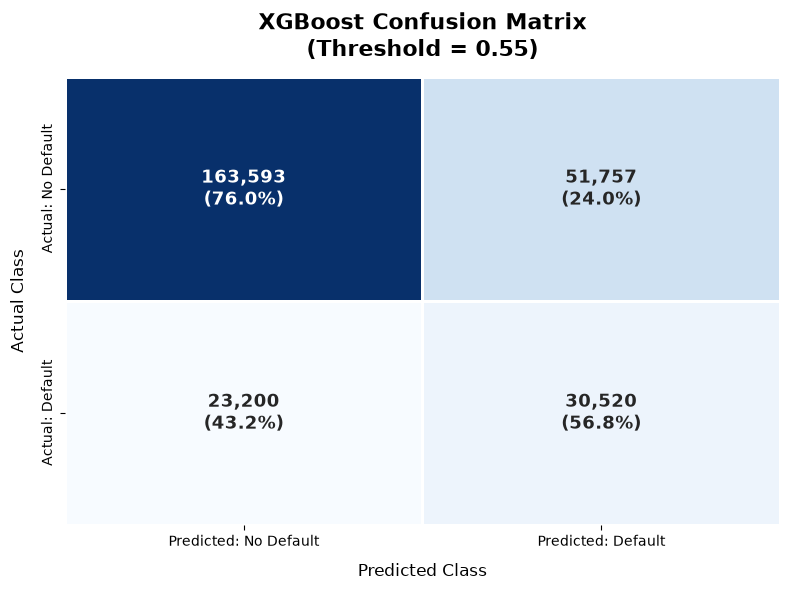

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Convert to percentages within each actual class
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create labels showing both count and percentage
labels = np.array([
    [f"{cm[i,j]:,}\n({cm_percent[i,j]:.1f}%)" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=labels,
    fmt='',
    cmap='Blues',
    cbar=False,
    linewidths=1,
    linecolor='white',
    xticklabels=['Predicted: No Default', 'Predicted: Default'],
    yticklabels=['Actual: No Default', 'Actual: Default'],
    annot_kws={'fontsize': 13, 'fontweight': 'bold'}
)

plt.title(
    'XGBoost Confusion Matrix\n(Threshold = 0.55)',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Predicted Class', fontsize=12, labelpad=10)
plt.ylabel('Actual Class', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()